# Two-hidden-layer MLP in PyTorch

Stack the layers with **`nn.Sequential`** — no custom `nn.Module` subclass. Hidden sizes are **256** and **128**. Adjust `input_dim` and `output_dim` to match your task.

In [2]:
import pandas as pd
import numpy as np
import sklearn

In [3]:
pbp_all = pd.read_csv("data/pbp_all.csv")

def add_score_time_pressure(df: pd.DataFrame) -> pd.DataFrame:
    """tanh(scoreDif / (secondsLeft + 1)): margin weighted by time remaining."""
    out = df.copy()
    out["scoreTimePressure"] = np.tanh(
        out["scoreDif"].to_numpy(dtype=np.float64)
        / (out["secondsLeft"].to_numpy(dtype=np.float64) + 1.0)
    )
    return out

pbp_all = add_score_time_pressure(pbp_all)

train_df = pbp_all[pbp_all["season"].isin(["2021-22", "2022-23", "2023-24"])]
val_df = pbp_all[pbp_all["season"] == "2024-25"]
test_df = pbp_all[pbp_all["season"] == "2025-26"]

In [4]:
# display max columns none
pd.set_option('display.max_columns', None)

In [5]:
train_df.head()

,season,gameId,gameDate,matchup,homeTeamId,homeAbbreviation,awayTeamId,awayAbbreviation,homeWin,description,quarter,periodSecondsLeft,secondsLeft,scoreHome,scoreAway,scoreDif,pointsTotal,actionTeamSide,possession,actionType,line,homeFouls,awayFouls,homeBonus,awayBonus,homeFreeThrows,awayFreeThrows,homeEjections,awayEjections,scoreTimePressure
0,2021-22,22100001,2021-10-19,MIL vs. BKN,1610612749,MIL,1610612751,BKN,1,Period Start,Q1,720.0,2880.0,0.0,0.0,0.0,0.0,NaN,0.5,period,1.5,0,0,0,0,0,0,0,0,0.0
1,2021-22,22100001,2021-10-19,MIL vs. BKN,1610612749,MIL,1610612751,BKN,1,Jump Ball B. Lopez vs. N. Claxton: Tip to G. A...,Q1,715.0,2875.0,0.0,0.0,0.0,0.0,home,1.0,jumpball,1.5,0,0,0,0,0,0,0,0,0.0
2,2021-22,22100001,2021-10-19,MIL vs. BKN,1610612749,MIL,1610612751,BKN,1,MISS G. Allen 26' 3PT,Q1,702.0,2862.0,0.0,0.0,0.0,0.0,home,0.3,3pt,1.5,0,0,0,0,0,0,0,0,0.0
3,2021-22,22100001,2021-10-19,MIL vs. BKN,1610612749,MIL,1610612751,BKN,1,K. Durant REBOUND (Off:0 Def:1),Q1,699.0,2859.0,0.0,0.0,0.0,0.0,away,0.0,rebound,1.5,0,0,0,0,0,0,0,0,0.0
4,2021-22,22100001,2021-10-19,MIL vs. BKN,1610612749,MIL,1610612751,BKN,1,G. Antetokounmpo shooting personal FOUL (1 PF)...,Q1,687.0,2847.0,0.0,0.0,0.0,0.0,home,0.0,foul,1.5,1,0,0,0,0,2,0,0,0.0


In [6]:
numeric_features = [
    "periodSecondsLeft",
    "secondsLeft",
    "scoreDif",
    "scoreTimePressure",
    "pointsTotal",
    "possession",
    "homeFouls",
    "awayFouls",
    "homeBonus",
    "awayBonus",
    "homeFreeThrows",
    "awayFreeThrows",
    "homeEjections",
    "awayEjections",
    "line"
]

one_hot_features = [
    "quarter"
]

target = [
    "homeWin"
]

In [7]:
_required = numeric_features + one_hot_features + target
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    n = df[_required].isna().any(axis=1).sum()
    print(name, int(n))
print("total", int(
    train_df[_required].isna().any(axis=1).sum()
    + val_df[_required].isna().any(axis=1).sum()
    + test_df[_required].isna().any(axis=1).sum()
))

train 37187
val 0
test 10908
total 48095


In [8]:
# Snapshot of rows with NaN in any model column (run before preprocessing / dropna)
from IPython.display import display

_required = numeric_features + one_hot_features + target

_nan_parts = []
for split_name, df in (("train", train_df), ("val", val_df), ("test", test_df)):
    m = df[_required].isna().any(axis=1)
    if m.any():
        _nan_parts.append(df.loc[m].assign(_split=split_name))

if not _nan_parts:
    print("No NaN values in model columns for train / val / test.")
else:
    nan_rows = pd.concat(_nan_parts)

    def _missing_cols(row):
        return [c for c in _required if pd.isna(row[c])]

    snap = nan_rows.assign(missing_columns=nan_rows.apply(_missing_cols, axis=1))

    # Which columns are missing most often?
    miss_series = snap["missing_columns"].explode()
    print("NaN counts by column (among rows with any NaN):")
    display(miss_series.value_counts().sort_values(ascending=False))

    context = [c for c in ("season", "gameId", "description") if c in snap.columns]
    show_cols = context + _required + ["missing_columns", "_split"]
    show_cols = [c for c in show_cols if c in snap.columns]

    out = snap[show_cols].copy()
    if "description" in out.columns:
        out["description"] = out["description"].astype(str).str.slice(0, 80)

    print(f"\nSample of rows (total with any NaN: {len(snap):,}):")
    display(out.head(5))

NaN counts by column (among rows with any NaN):


missing_columns
line          48093
possession        2
Name: count, dtype: int64


Sample of rows (total with any NaN: 48,095):


,season,gameId,description,periodSecondsLeft,secondsLeft,scoreDif,scoreTimePressure,pointsTotal,possession,homeFouls,awayFouls,homeBonus,awayBonus,homeFreeThrows,awayFreeThrows,homeEjections,awayEjections,line,quarter,homeWin,missing_columns,_split
231168,2021-22,22100529,Period Start,720.0,2880.0,0.0,0.000000,0.0,0.5,0,0,0,0,0,0,0,0,NaN,Q1,1,[line],train
231169,2021-22,22100529,Jump Ball R. Williams III vs. J. Smith: Tip to...,716.0,2876.0,0.0,0.000000,0.0,1.0,0,0,0,0,0,0,0,0,NaN,Q1,1,[line],train
231170,2021-22,22100529,M. Smart cutting finger roll Layup (2 PTS) (R....,706.0,2866.0,2.0,0.000698,2.0,0.0,0,0,0,0,0,0,0,0,NaN,Q1,1,[line],train
231171,2021-22,22100529,J. Smith 19' Jump Shot (2 PTS) (M. Bridges 1 AST),689.0,2849.0,0.0,0.000000,4.0,1.0,0,0,0,0,0,0,0,0,NaN,Q1,1,[line],train
231172,2021-22,22100529,M. Smart 19' pullup Jump Shot (4 PTS) (A. Horf...,664.0,2824.0,2.0,0.000708,6.0,0.0,0,0,0,0,0,0,0,0,NaN,Q1,1,[line],train


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
import joblib

# Rows with NaN in any model input or target break training.
# Numeric standardization lives in the PyTorch MLP (train-set mean/std buffers).
_required = numeric_features + one_hot_features + target
feature_cols = numeric_features + one_hot_features
n_numeric = len(numeric_features)


def _drop_nan_rows(df, name):
    n = len(df)
    out = df.dropna(subset=_required).copy()
    print(f"{name}: dropped {n - len(out):,} rows with NaN in model columns ({len(out):,} remaining)")
    return out


train_df = add_score_time_pressure(train_df)
val_df = add_score_time_pressure(val_df)
test_df = add_score_time_pressure(test_df)

train_df = _drop_nan_rows(train_df, "train")
val_df = _drop_nan_rows(val_df, "val")
test_df = _drop_nan_rows(test_df, "test")

# Fitted on train only: passthrough numerics + one-hot categoricals
preprocess = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("oh", OneHotEncoder(handle_unknown="ignore", sparse_output=False), one_hot_features),
    ],
)

feature_pipeline = Pipeline([("preprocess", preprocess)])
feature_pipeline.fit(train_df[feature_cols])

splits = (("train", train_df), ("val", val_df), ("test", test_df))
X_splits, y_splits = {}, {}
for name, df in splits:
    X_splits[name] = feature_pipeline.transform(df[feature_cols]).astype(np.float32)
    y_splits[name] = df[target].values.astype(np.float32).ravel()

X_train, X_val, X_test = X_splits["train"], X_splits["val"], X_splits["test"]
y_train, y_val, y_test = y_splits["train"], y_splits["val"], y_splits["test"]
n_onehot = X_train.shape[1] - n_numeric

if not np.isfinite(X_train).all() or not np.isfinite(y_train).all():
    raise ValueError("Non-finite values in X_train or y_train after preprocessing")

joblib.dump(feature_pipeline, "feature_pipeline.joblib")
print(
    f"Saved feature_pipeline.joblib (features={X_train.shape[1]}: "
    f"{n_numeric} numeric + {n_onehot} one-hot; scaling in MLP)"
)

train: dropped 37,187 rows with NaN in model columns (1,546,485 remaining)
val: dropped 0 rows with NaN in model columns (522,221 remaining)
test: dropped 10,908 rows with NaN in model columns (521,897 remaining)
Saved feature_pipeline.joblib (features=20: 15 numeric + 5 one-hot; scaling in MLP)


May want to make sure the dropped rows come from only a few games

In [10]:
X_train.shape

(1546485, 20)

In [11]:
# ── Parallel grid search ────────────────────────────────────────────────────────
# Numeric columns are z-scored inside MLP (train mean/std buffers). sklearn pipeline
# only one-hot encodes categoricals.

import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import joblib
from joblib import Parallel, delayed


def _numeric_scale_stats(X: np.ndarray, n_numeric: int):
    mean = X[:, :n_numeric].mean(axis=0)
    std = X[:, :n_numeric].std(axis=0)
    std[std == 0] = 1.0
    return mean.astype(np.float32), std.astype(np.float32)


class MLP(nn.Module):
    """MLP with train-set standardization on the first n_numeric columns."""

    def __init__(
        self,
        n_numeric: int,
        n_onehot: int,
        hidden_layers,
        output_dim: int = 1,
        num_mean: torch.Tensor | None = None,
        num_std: torch.Tensor | None = None,
    ):
        super().__init__()
        self.n_numeric = n_numeric
        self.n_onehot = n_onehot
        input_dim = n_numeric + n_onehot

        if num_mean is None:
            num_mean = torch.zeros(n_numeric)
        if num_std is None:
            num_std = torch.ones(n_numeric)
        self.register_buffer("num_mean", num_mean.float().view(1, -1))
        self.register_buffer("num_std", num_std.float().view(1, -1))

        dims = [input_dim] + list(hidden_layers) + [output_dim]
        layers = []
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            if i < len(dims) - 2:
                layers.append(nn.ReLU())
        self.net = nn.Sequential(*layers)

    @classmethod
    def from_train_matrix(cls, X_train: np.ndarray, hidden_layers, n_numeric: int):
        mean, std = _numeric_scale_stats(X_train, n_numeric)
        n_onehot = X_train.shape[1] - n_numeric
        return cls(
            n_numeric,
            n_onehot,
            hidden_layers,
            num_mean=torch.tensor(mean),
            num_std=torch.tensor(std),
        )

    def _encode(self, x: torch.Tensor) -> torch.Tensor:
        num = (x[:, : self.n_numeric] - self.num_mean) / self.num_std
        if self.n_onehot == 0:
            return num
        return torch.cat([num, x[:, self.n_numeric :]], dim=1)

    def forward(self, x):
        return self.net(self._encode(x))


class WinProbPipeline:
    """sklearn feature encoding + PyTorch MLP (with built-in numeric scaling)."""

    def __init__(self, feature_pipeline, mlp: MLP, feature_cols: list[str]):
        self.feature_pipeline = feature_pipeline
        self.mlp = mlp
        self.feature_cols = feature_cols

    def _transform(self, df) -> torch.Tensor:
        X = self.feature_pipeline.transform(df[self.feature_cols]).astype(np.float32)
        return torch.tensor(X)

    @torch.no_grad()
    def predict_proba(self, df) -> np.ndarray:
        self.mlp.eval()
        probs = torch.sigmoid(self.mlp(self._transform(df))).detach().cpu().numpy()
        return np.asarray(probs, dtype=np.float64).reshape(-1)

    def save(self, prefix: str = "wp_model") -> None:
        joblib.dump(self.feature_pipeline, f"{prefix}_feature_pipeline.joblib")
        torch.save(
            {
                "state_dict": self.mlp.state_dict(),
                "n_numeric": self.mlp.n_numeric,
                "n_onehot": self.mlp.n_onehot,
                "hidden_layers": [
                    layer.out_features
                    for layer in self.mlp.net
                    if isinstance(layer, nn.Linear)
                ][:-1],
                "feature_cols": self.feature_cols,
            },
            f"{prefix}_mlp.pt",
        )

    @classmethod
    def load(cls, prefix: str = "wp_model") -> "WinProbPipeline":
        fp = joblib.load(f"{prefix}_feature_pipeline.joblib")
        ckpt = torch.load(f"{prefix}_mlp.pt", weights_only=False)
        hidden = ckpt["hidden_layers"]
        mlp = MLP(ckpt["n_numeric"], ckpt["n_onehot"], hidden)
        mlp.load_state_dict(ckpt["state_dict"])
        mlp.eval()
        return cls(fp, mlp, ckpt["feature_cols"])

# ── Worker function (serialised via cloudpickle by joblib/loky) ────────────────
def _train_combo(
    X_train, y_train, X_val, y_val,
    hidden_layers, lr, optimizer_name, weight_decay, num_epochs, batch_size,
    n_numeric,
):
    os.environ["OMP_NUM_THREADS"] = "1"
    os.environ["MKL_NUM_THREADS"] = "1"
    torch.set_num_threads(1)

    Xtr = torch.tensor(X_train, dtype=torch.float32)
    ytr = torch.tensor(y_train, dtype=torch.float32)
    Xva = torch.tensor(X_val,   dtype=torch.float32)
    yva = torch.tensor(y_val,   dtype=torch.float32)

    model = MLP.from_train_matrix(X_train, hidden_layers, n_numeric)
    criterion = nn.BCEWithLogitsLoss()

    print(f"[DEBUG] worker received weight_decay={weight_decay}, optimizer={optimizer_name}", flush=True)
    opt_cls = {"adamw": optim.AdamW, "adam": optim.Adam, "sgd": optim.SGD, "rmsprop": optim.RMSprop}
    if optimizer_name.lower() not in opt_cls:
        raise ValueError(f"Unknown optimizer {optimizer_name!r}. Choose from: {list(opt_cls)}")
    optimizer = opt_cls[optimizer_name.lower()](
        model.parameters(), lr=lr, weight_decay=weight_decay
    )

    arch_str = "x".join(str(h) for h in hidden_layers)
    key = f"arch={arch_str},lr={lr},opt={optimizer_name},wd={weight_decay}"

    # epoch-0 baseline (random init, no training)
    model.eval()
    with torch.no_grad():
        init_val_logits = model(Xva)
        init_val_loss   = criterion(init_val_logits, yva.view(-1, 1)).item()
        init_train_logits = model(Xtr)
        init_train_loss   = criterion(init_train_logits, ytr.view(-1, 1)).item()

    train_losses = [init_train_loss]
    val_losses   = [init_val_loss]

    for epoch in range(num_epochs):
        model.train()
        perm       = torch.randperm(Xtr.size(0))
        epoch_loss = 0.0
        for i in range(0, Xtr.size(0), batch_size):
            idx = perm[i : i + batch_size]
            bx, by = Xtr[idx], ytr[idx].view(-1, 1)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * bx.size(0)

        avg_train = epoch_loss / Xtr.size(0)
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(Xva), yva.view(-1, 1)).item()

        train_losses.append(avg_train)
        val_losses.append(val_loss)
        nan_flag = " *** NaN DETECTED ***" if (avg_train != avg_train or val_loss != val_loss) else ""
        print(
            f"epoch {epoch+1}/{num_epochs} ({key}) "
            f"train={avg_train:.6f}  val={val_loss:.6f}{nan_flag}",
            flush=True,
        )

    model.eval()
    with torch.no_grad():
        val_probs = torch.sigmoid(model(Xva)).view(-1)
        yva_flat  = yva.view(-1)

    val_brier = ((val_probs - yva_flat) ** 2).mean().item()

    return key, {"train_losses": train_losses, "val_losses": val_losses, "val_brier": val_brier}


## Train and save final model

End-to-end `WinProbPipeline`: sklearn one-hot encoding + PyTorch MLP (train-set numeric scaling in `forward`).

- **8** hidden units (`arch=[8]`)
- **0.01** weight decay (AdamW L2)
- **0.001** learning rate (step size)
- **2048** batch size

In [25]:
# ── Final model: train and save WinProbPipeline ───────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(10)
np.random.seed(10)

hidden_layers = [8]
lr = 0.01
batch_size = 2048
optimizer_name = "Adam"
num_epochs = 10

Xtr = torch.tensor(X_train, dtype=torch.float32)
ytr = torch.tensor(y_train, dtype=torch.float32)
Xva = torch.tensor(X_val, dtype=torch.float32)
yva = torch.tensor(y_val, dtype=torch.float32)

model = MLP.from_train_matrix(X_train, hidden_layers, n_numeric)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

key = f"arch=8,lr={lr},opt={optimizer_name},wd={weight_decay}"
print(f"Training final model ({key}), batch_size={batch_size}, epochs={num_epochs}")

for epoch in range(num_epochs):
    model.train()
    perm = torch.randperm(Xtr.size(0))
    epoch_loss = 0.0
    for i in range(0, Xtr.size(0), batch_size):
        idx = perm[i : i + batch_size]
        bx, by = Xtr[idx], ytr[idx].view(-1, 1)
        optimizer.zero_grad()
        loss = criterion(model(bx), by)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * bx.size(0)
    avg_train = epoch_loss / Xtr.size(0)
    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(Xva), yva.view(-1, 1)).item()
    print(f"epoch {epoch+1}/{num_epochs} train={avg_train:.6f} val={val_loss:.6f}")

wp_pipeline = WinProbPipeline(feature_pipeline, model, feature_cols)
val_probs = wp_pipeline.predict_proba(val_df)
val_brier = float(np.mean((val_probs - np.asarray(y_val).ravel()) ** 2))
print(f"Final val Brier: {val_brier:.6f}")

wp_pipeline.save("wp_model")
print("Saved wp_model_feature_pipeline.joblib and wp_model_mlp.pt (includes num_mean/num_std)")

Training final model (arch=8,lr=0.01,opt=Adam,wd=0.01), batch_size=2048, epochs=10
epoch 1/10 train=0.462330 val=0.441493
epoch 2/10 train=0.454606 val=0.440923
epoch 3/10 train=0.454046 val=0.442492
epoch 4/10 train=0.453783 val=0.441709
epoch 5/10 train=0.453619 val=0.441598
epoch 6/10 train=0.453621 val=0.441673
epoch 7/10 train=0.453487 val=0.440978
epoch 8/10 train=0.453468 val=0.441913
epoch 9/10 train=0.453518 val=0.440650
epoch 10/10 train=0.453471 val=0.441945
Final val Brier: 0.146869
Saved wp_model_feature_pipeline.joblib and wp_model_mlp.pt (includes num_mean/num_std)


## Load saved model and run experiments

Run the **MLP / WinProbPipeline** definition cell once per kernel session (defines `WinProbPipeline.load`).

Requires `wp_model_feature_pipeline.joblib` and `wp_model_mlp.pt` from the training cell above.

For experiments, use `exp_df` (built below). Training still uses `val_df` / `test_df`.

In [26]:
from pathlib import Path

MODEL_PREFIX = "wp_model"

for name in (
    f"{MODEL_PREFIX}_feature_pipeline.joblib",
    f"{MODEL_PREFIX}_mlp.pt",
):
    if not Path(name).is_file():
        raise FileNotFoundError(f"Missing {name} — run the train/save cell first.")

wp_model = WinProbPipeline.load(MODEL_PREFIX)
print(
    f"Loaded {MODEL_PREFIX}: "
    f"{wp_model.mlp.n_numeric} numeric + {wp_model.mlp.n_onehot} one-hot features"
)
print(f"Columns ({len(wp_model.feature_cols)}): {wp_model.feature_cols}")

Loaded wp_model: 15 numeric + 5 one-hot features
Columns (16): ['periodSecondsLeft', 'secondsLeft', 'scoreDif', 'scoreTimePressure', 'pointsTotal', 'possession', 'homeFouls', 'awayFouls', 'homeBonus', 'awayBonus', 'homeFreeThrows', 'awayFreeThrows', 'homeEjections', 'awayEjections', 'line', 'quarter']


In [27]:
val_df["winProb"] = wp_model.predict_proba(val_df)

def seconds_to_timestamp(seconds):
    if pd.isna(seconds):
        return np.nan
    seconds = float(seconds)
    if seconds < 10:
        secs = int(seconds)
        tenths = int(round((seconds - secs) * 10))
        if tenths == 10:
            secs += 1
            tenths = 0
        return f"0:{secs:02d}.{tenths:01d}"
    minutes = int(seconds // 60)
    secs = int(seconds % 60)
    return f"{minutes}:{secs:02d}"

if "periodSecondsLeft" in val_df.columns:
    val_df["timestamp"] = val_df["periodSecondsLeft"].apply(seconds_to_timestamp)

val_df.head()

,season,gameId,gameDate,matchup,homeTeamId,homeAbbreviation,awayTeamId,awayAbbreviation,homeWin,description,quarter,periodSecondsLeft,secondsLeft,scoreHome,scoreAway,scoreDif,pointsTotal,actionTeamSide,possession,actionType,line,homeFouls,awayFouls,homeBonus,awayBonus,homeFreeThrows,awayFreeThrows,homeEjections,awayEjections,scoreTimePressure,winProb,timestamp
1583672,2024-25,22400001,2024-11-12,BOS vs. ATL,1610612738,BOS,1610612737,ATL,0,Period Start,Q1,720.0,2880.0,0.0,0.0,0.0,0.0,NaN,0.5,period,-16.0,0,0,0,0,0,0,0,0,0.0,0.871782,12:00
1583673,2024-25,22400001,2024-11-12,BOS vs. ATL,1610612738,BOS,1610612737,ATL,0,Jump Ball C. Capela vs. A. Horford: Tip to K. ...,Q1,718.0,2878.0,0.0,0.0,0.0,0.0,away,0.0,jumpball,-16.0,0,0,0,0,0,0,0,0,0.0,0.871575,11:58
1583674,2024-25,22400001,2024-11-12,BOS vs. ATL,1610612738,BOS,1610612737,ATL,0,MISS Z. Risacher 26' 3PT - blocked,Q1,703.0,2863.0,0.0,0.0,0.0,0.0,away,0.7,3pt,-16.0,0,0,0,0,0,0,0,0,0.0,0.872457,11:43
1583675,2024-25,22400001,2024-11-12,BOS vs. ATL,1610612738,BOS,1610612737,ATL,0,J. Tatum BLOCK (1 BLK),Q1,703.0,2863.0,0.0,0.0,0.0,0.0,home,0.0,block,-16.0,0,0,0,0,0,0,0,0,0.0,0.872075,11:43
1583676,2024-25,22400001,2024-11-12,BOS vs. ATL,1610612738,BOS,1610612737,ATL,0,Z. Risacher REBOUND (Off:1 Def:0),Q1,702.0,2862.0,0.0,0.0,0.0,0.0,away,0.0,rebound,-16.0,0,0,0,0,0,0,0,0,0.0,0.872109,11:42


In [28]:
val_df.columns

Index(['season', 'gameId', 'gameDate', 'matchup', 'homeTeamId',
       'homeAbbreviation', 'awayTeamId', 'awayAbbreviation', 'homeWin',
       'description', 'quarter', 'periodSecondsLeft', 'secondsLeft',
       'scoreHome', 'scoreAway', 'scoreDif', 'pointsTotal', 'actionTeamSide',
       'possession', 'actionType', 'line', 'homeFouls', 'awayFouls',
       'homeBonus', 'awayBonus', 'homeFreeThrows', 'awayFreeThrows',
       'homeEjections', 'awayEjections', 'scoreTimePressure', 'winProb',
       'timestamp'],
      dtype='object')

In [29]:
exp_df = val_df[["gameId", "season", "gameDate", "matchup", "homeWin", "winProb", "quarter", "timestamp", "scoreHome", "scoreAway", "description", "possession"]]
exp_df.head()

,gameId,season,gameDate,matchup,homeWin,winProb,quarter,timestamp,scoreHome,scoreAway,description,possession
1583672,22400001,2024-25,2024-11-12,BOS vs. ATL,0,0.871782,Q1,12:00,0.0,0.0,Period Start,0.5
1583673,22400001,2024-25,2024-11-12,BOS vs. ATL,0,0.871575,Q1,11:58,0.0,0.0,Jump Ball C. Capela vs. A. Horford: Tip to K. ...,0.0
1583674,22400001,2024-25,2024-11-12,BOS vs. ATL,0,0.872457,Q1,11:43,0.0,0.0,MISS Z. Risacher 26' 3PT - blocked,0.7
1583675,22400001,2024-25,2024-11-12,BOS vs. ATL,0,0.872075,Q1,11:43,0.0,0.0,J. Tatum BLOCK (1 BLK),0.0
1583676,22400001,2024-25,2024-11-12,BOS vs. ATL,0,0.872109,Q1,11:42,0.0,0.0,Z. Risacher REBOUND (Off:1 Def:0),0.0


In [30]:
import matplotlib.pyplot as plt


def _quarter_ticks(game: pd.DataFrame, time_col: str, quarter_col: str):
    """Tick positions (minutes elapsed) and labels (Q1, Q2, …) at each period start."""
    order, seen = [], set()
    for q in game[quarter_col]:
        if q not in seen:
            order.append(q)
            seen.add(q)
    positions, labels = [], []
    for q in order:
        sub = game.loc[game[quarter_col] == q, time_col]
        positions.append(float(sub.min()))
        labels.append(str(q))
    return positions, labels


def plot_wp(
    game_id,
    df: pd.DataFrame | None = None,
    pipeline=None,
    *,
    game_id_col: str = "gameId",
    prob_col: str = "winProb",
    time_col: str = "secondsLeft",
    quarter_col: str = "quarter",
    matchup_col: str = "matchup",
    home_win_col: str = "homeWin",
    ax=None,
    figsize=(12, 5),
):
    """Plot home win probability over game time; x-axis ticks labeled by quarter."""
    if df is None:
        df = val_df
    if pipeline is None:
        pipeline = wp_model

    gid = game_id
    if np.issubdtype(type(df[game_id_col].iloc[0]), np.number):
        try:
            gid = int(game_id)
        except (TypeError, ValueError):
            pass

    game = df.loc[df[game_id_col] == gid].copy()
    if game.empty:
        raise ValueError(f"No rows for {game_id_col}={game_id!r}")

    ok = game[pipeline.feature_cols].notna().all(axis=1)
    if prob_col not in game.columns or game.loc[ok, prob_col].isna().all():
        game[prob_col] = np.nan
        if ok.any():
            game.loc[ok, prob_col] = pipeline.predict_proba(game.loc[ok])
    game = game.dropna(subset=[prob_col])
    if game.empty:
        raise ValueError(f"No scorable rows for game {game_id!r}")

    t_start = game[time_col].max()
    game["minutes_elapsed"] = (t_start - game[time_col]) / 60.0
    game = game.sort_values("minutes_elapsed")

    if ax is None:
        _, ax = plt.subplots(figsize=figsize)

    ax.plot(
        game["minutes_elapsed"],
        game[prob_col],
        color="#1f77b4",
        lw=1.5,
        label="P(home win)",
    )
    ax.axhline(0.5, color="gray", ls="--", lw=1, alpha=0.7)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Home win probability")

    tick_pos, tick_labels = _quarter_ticks(game, "minutes_elapsed", quarter_col)
    for x in tick_pos[1:]:
        ax.axvline(x, color="lightgray", lw=0.8, alpha=0.8)
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels)
    ax.set_xlabel("Quarter")

    title_parts = [f"Game {gid}"]
    if matchup_col in game.columns:
        title_parts.append(str(game[matchup_col].iloc[0]))
    if home_win_col in game.columns:
        hw = game[home_win_col].iloc[-1]
        title_parts.append(f"(home {'won' if hw else 'lost'})")
    ax.set_title(" — ".join(title_parts))
    ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()


# Example:
# plot_wp(22400001)
# plt.show()


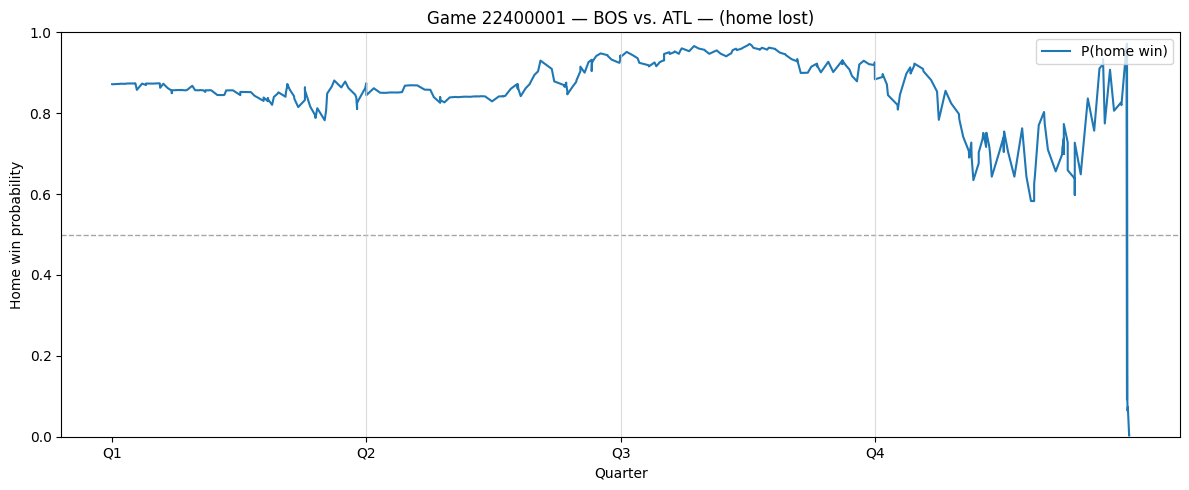

In [31]:
plot_wp(22400001)

### To Do
 Feature Importance
 Compare with ESPN
 Add New Features